## $\text{IDR to USD Exchange Rate Prediction}$

#### $\text{1. Import Dependencies}$

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
import optuna
import joblib
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Times New Roman'

#### $\text{2. Load the Processed Dataset}$

In [2]:
data = pd.read_csv('C:/Python Programming/idr2usd-exchange-rate/data/processed/idr2usd-exchange-rate-processed.csv')
data

,Index,Bulan,USD
0,305,Mei 2026,17789.0
1,304,April 2026,17324.0
2,303,Maret 2026,16993.0
3,302,Februari 2026,16758.0
4,301,Januari 2026,16786.0
...,...,...,...
300,5,Mei 2001,11058.0
301,4,April 2001,11675.0
302,3,Maret 2001,10400.0
303,2,Februari 2001,9835.0


#### $\text{3. Train Test Split Setup}$

In [3]:
# The Desired Data
X = data['Index'].values.reshape(-1, 1)
y = data['USD'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((244, 1), (61, 1), (244, 1), (61, 1))

#### $\text{4. Hyperparameter Tuning}$

In [4]:
def objective(trial):
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=trial.suggest_categorical(
                "hidden_layer_sizes", [(32,), (64,), (128,), (64, 32), (128, 64)]
            ),
            activation=trial.suggest_categorical(
                "activation", ["relu", "tanh"]
            ),
            solver=trial.suggest_categorical(
                "solver", ["adam", "lbfgs"]
            ),
            alpha=trial.suggest_float(
                "alpha", 1e-5, 1e-1, log=True
            ),
            learning_rate_init=trial.suggest_float(
                "learning_rate_init", 1e-4, 1e-2, log=True
            ),
            early_stopping=True,
            max_iter=500,
            random_state=42
        ))
    ])

    score = cross_val_score(pipeline, X_train, y_train, cv=3, scoring="r2", n_jobs=-1)
    
    return score.mean()

In [5]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

[I 2026-07-17 13:04:44,598] A new study created in memory with name: no-name-8fe05540-a09c-4ec4-8447-03de210342f9
c:\Python Programming\idr2usd-exchange-rate\.venv\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (32,) which is of type tuple.
  optuna_warn(message)
c:\Python Programming\idr2usd-exchange-rate\.venv\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (64,) which is of type tuple.
  optuna_warn(message)
c:\Python Programming\idr2usd-exchange-rate\.venv\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (128,) which is of type tuple.
  optuna_warn(message)
c:\Python Progr

In [6]:
best_score = study.best_value
best_score

0.9726796889783262

In [7]:
best_parameters = study.best_params
best_parameters

{'hidden_layer_sizes': (128, 64),
 'activation': 'relu',
 'solver': 'lbfgs',
 'alpha': 0.007651441865567043,
 'learning_rate_init': 0.0002529587308130414}

In [8]:
optuna.visualization.plot_param_importances(study)

#### $\text{5. Validation}$

In [9]:
best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(**best_parameters))
])

best_model.fit(X_train, y_train)

c:\Python Programming\idr2usd-exchange-rate\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1775: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Python Programming\idr2usd-exchange-rate\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](1,)",[153.2]


In [10]:
y_pred = best_model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred)}")

R2 Score: 0.9790528541433893


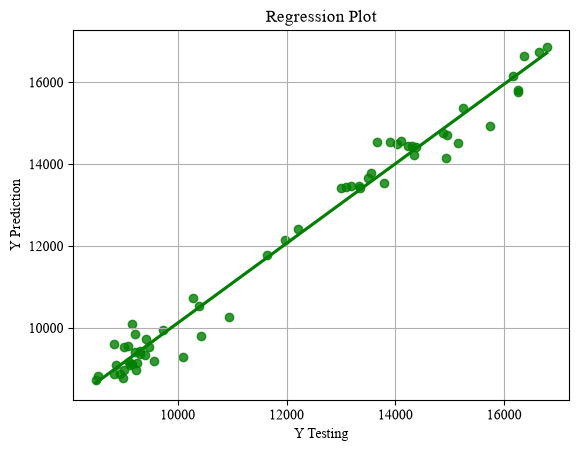

In [11]:
# Regression Plot
sns.regplot(
    x=y_test,
    y=y_pred,
    ci=None,
    color='g'
)

plt.title("Regression Plot")
plt.xlabel("Y Testing")
plt.ylabel("Y Prediction")
plt.grid(True)

plt.show()

In [12]:
X_new = np.arange(0, 401, 1).reshape(-1, 1)

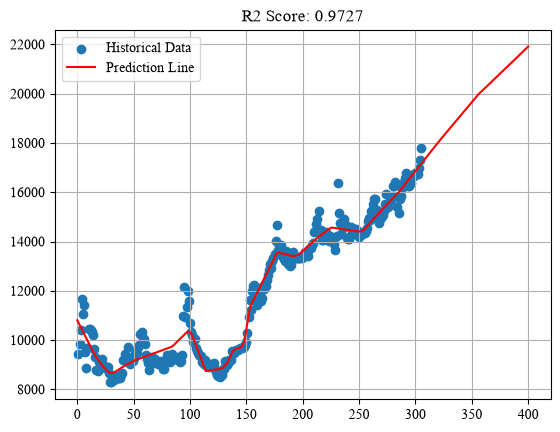

In [13]:
plt.scatter(X, y, label='Historical Data')
plt.plot(X_new, best_model.predict(X_new), color='red', label='Prediction Line')
plt.title(f"R2 Score: {best_score:.4f}")
plt.legend()
plt.grid()
plt.show()

#### $\text{6. Save the Best Model}$

In [15]:
joblib.dump(best_model, 'C:/Python Programming/idr2usd-exchange-rate/models/model.pkl')

['C:/Python Programming/idr2usd-exchange-rate/models/model.pkl']